# Capstone Project - EDA: Ames Housing (House Prices)
## Phân tích đa biến (Multivariate Analysis)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

df = pd.read_csv('train.csv')
num_df = df.select_dtypes(include=[np.number])
num_df.shape

(1460, 38)

## 1. Tương quan các biến số với SalePrice

Top 10 bien tuong quan manh nhat voi SalePrice:
 OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
Name: SalePrice, dtype: float64


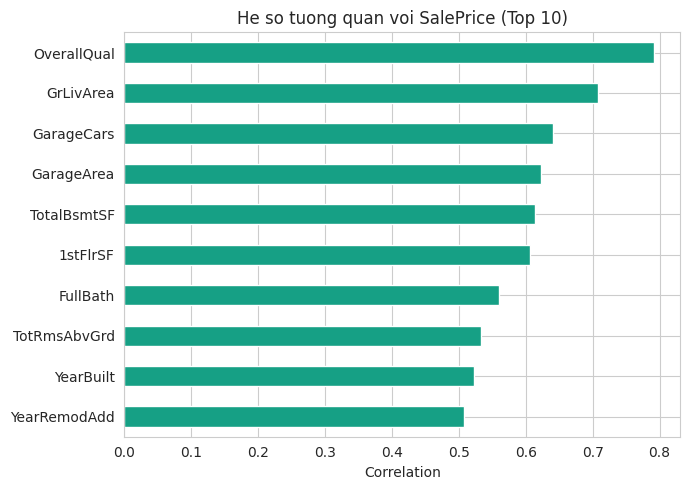

In [2]:
corr_target = num_df.corr()['SalePrice'].sort_values(ascending=False)
top_corr = corr_target.drop('SalePrice').head(10)
print("Top 10 biến tương quan mạnh nhất với SalePrice:\n", top_corr.round(3))

plt.figure(figsize=(7,5))
top_corr.sort_values().plot(kind='barh', color='#16a085')
plt.title('Hệ số tương quan với SalePrice (Top 10)')
plt.xlabel('Hệ số tương quan')
plt.tight_layout()
plt.show()

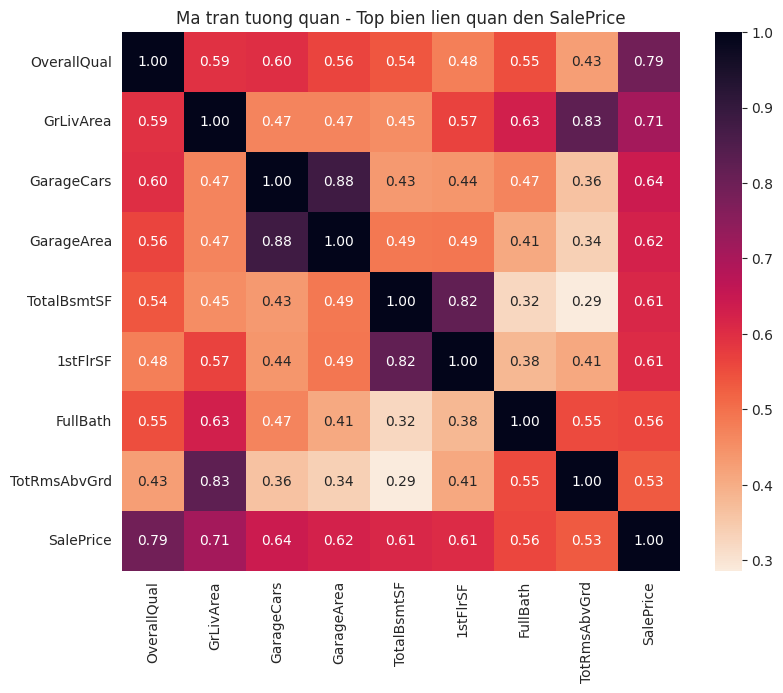

In [3]:
top_features = top_corr.head(8).index.tolist()
plt.figure(figsize=(9,7))
sns.heatmap(num_df[top_features + ['SalePrice']].corr(), annot=True, fmt='.2f', cmap='rocket_r')
plt.title('Ma trận tương quan - Top biến liên quan đến SalePrice')
plt.show()

**Nhận xét:** `OverallQual` (chất lượng tổng thể) có tương quan mạnh nhất với `SalePrice` (~0.79), theo sau là `GrLivArea` (diện tích sàn ở ~0.71), `GarageCars`/`GarageArea` (~0.62-0.64), `TotalBsmtSF` và `1stFlrSF` (~0.61). Các biến này đều liên quan trực tiếp đến **kích thước và chất lượng** của ngôi nhà nên khá đáng chú ý khi phân tích giá bán.


## 2. Quan hệ giữa diện tích và giá bán

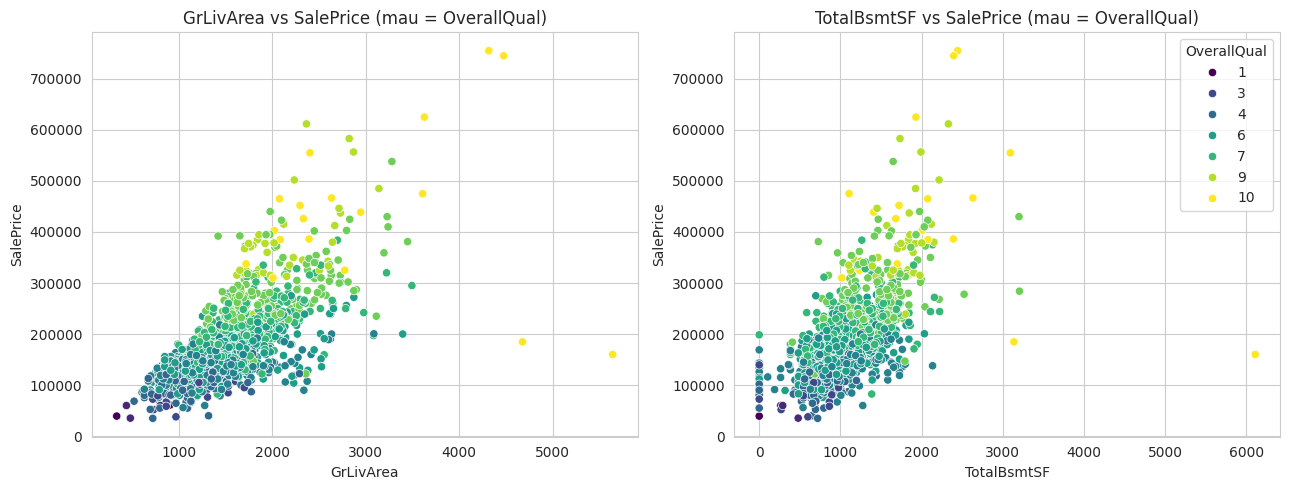

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, hue='OverallQual', palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('GrLivArea và SalePrice (màu = OverallQual)')
sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=df, hue='OverallQual', palette='viridis', ax=axes[1])
axes[1].set_title('TotalBsmtSF và SalePrice (màu = OverallQual)')
plt.tight_layout()
plt.show()

**Nhận xét:** `SalePrice` có xu hướng tăng khi diện tích (`GrLivArea`, `TotalBsmtSF`) tăng, nhưng quan hệ không hoàn toàn tuyến tính. Ở cùng một mức diện tích, những căn có `OverallQual` cao thường có giá cao hơn. Qua đó có thể thấy cả **chất lượng** và **kích thước** đều là những yếu tố cần quan tâm khi phân tích giá nhà.


## 2.1. Bổ sung pairplot cho một số biến chính

Tutorial có sử dụng `pairplot` để quan sát nhiều mối quan hệ cùng lúc. Với bộ dữ liệu Ames có nhiều cột nên chỉ chọn một số biến tiêu biểu để biểu đồ dễ quan sát hơn.


In [ ]:
cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars']
sns.pairplot(df[cols].dropna())
plt.show()


**Nhận xét bổ sung:** Pairplot cho thấy `SalePrice` có xu hướng tăng khi `OverallQual`, `GrLivArea` và `TotalBsmtSF` tăng. Một số biến diện tích cũng có quan hệ với nhau, vì vậy khi xây dựng mô hình cần chú ý khả năng các biến mang thông tin trùng nhau.

Từ các biểu đồ trên có thể nhận thấy mối quan hệ giữa diện tích, chất lượng và giá bán. Tuy nhiên, chỉ dựa vào EDA thì chưa đủ để khẳng định có **tương tác thống kê** giữa các biến. Phần EDA chủ yếu dùng để nhìn xu hướng và đưa ra gợi ý cho bước xây dựng mô hình tiếp theo.


## 3. Giá bán theo chất lượng tổng thể (OverallQual) và vị trí (Neighborhood)

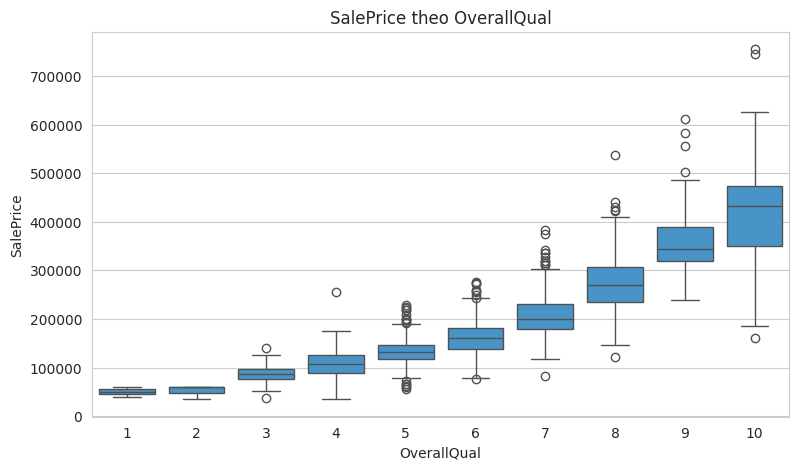

In [5]:
plt.figure(figsize=(9,5))
sns.boxplot(x='OverallQual', y='SalePrice', data=df, color='#3498db')
plt.title('SalePrice theo OverallQual')
plt.show()

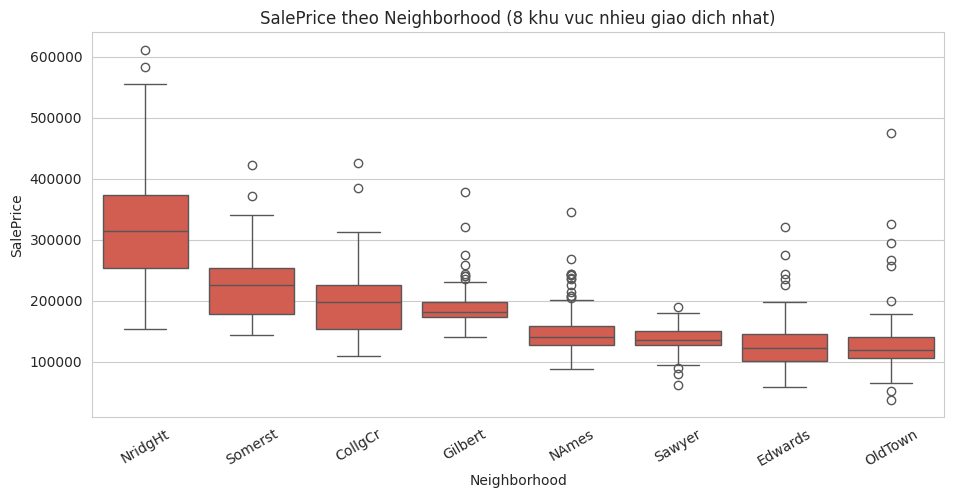

In [6]:
top_n = df['Neighborhood'].value_counts().head(8).index
plt.figure(figsize=(11,5))
order = df[df['Neighborhood'].isin(top_n)].groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index
sns.boxplot(x='Neighborhood', y='SalePrice', data=df[df['Neighborhood'].isin(top_n)], order=order, color='#e74c3c')
plt.title('SalePrice theo Neighborhood (8 khu vực có nhiều giao dịch nhất)')
plt.xticks(rotation=30)
plt.show()

**Nhận xét:**
- `SalePrice` tăng khá đều theo `OverallQual`: từ mức 1-10, giá trung vị tăng mạnh, đặc biệt từ mức 7 trở lên.
- Giữa các khu vực (`Neighborhood`), chênh lệch giá trung vị khá lớn. Ví dụ, **NridgHt/Somerst** có mức giá trung vị cao hơn **OldTown/Edwards** khá rõ. Điều này cho thấy vị trí là một biến phân loại đáng chú ý khi phân tích giá và khi xây dựng mô hình.


## 4. Quan hệ giữa năm xây/năm sửa chữa và giá bán

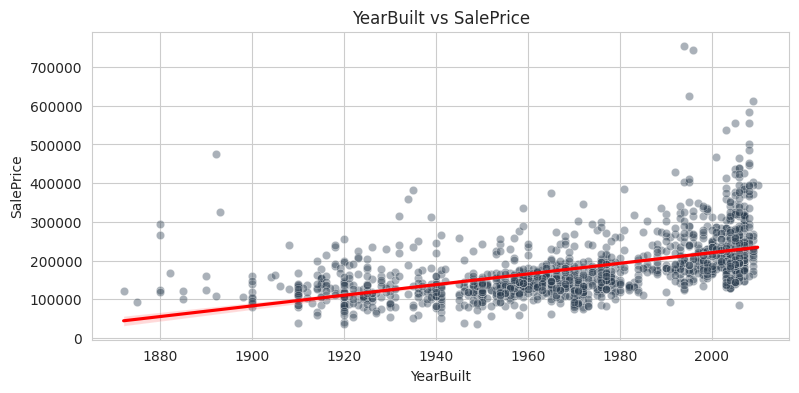

In [7]:
fig, ax = plt.subplots(figsize=(9,4))
sns.scatterplot(x='YearBuilt', y='SalePrice', data=df, alpha=0.4, color='#2c3e50')
sns.regplot(x='YearBuilt', y='SalePrice', data=df, scatter=False, color='red', ax=ax)
plt.title('YearBuilt và SalePrice')
plt.show()

**Nhận xét:** Có xu hướng giá bán tăng nhẹ theo năm xây, tức là những căn nhà mới hơn thường có giá trung bình cao hơn. Tuy nhiên, mức độ phân tán vẫn khá lớn nên `YearBuilt` không thể giải thích toàn bộ sự thay đổi của giá bán.


## 5. Kết luận

- `OverallQual`, `GrLivArea`, `GarageCars`/`GarageArea`, `TotalBsmtSF` là những biến có tương quan khá mạnh với `SalePrice` và đáng được chú ý khi xây dựng mô hình dự đoán.
- Cả **kích thước** và **chất lượng** đều có mối quan hệ với giá bán; qua các biểu đồ có thể thấy nhà có kích thước lớn nhưng chất lượng thấp chưa chắc có giá cao hơn nhà nhỏ hơn nhưng chất lượng tốt.
- **Vị trí (`Neighborhood`)** tạo ra sự chênh lệch giá khá rõ giữa các khu vực, nên đây là một biến phân loại quan trọng.
